---
#### 4-2. ML 실습 - 분류3(다중분류) 
- 농작물 잔류농약 여부 예측 
---

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 한글데이터 사용 
sns.set_theme(style='whitegrid')
import koreanize_matplotlib 
# 경고메시지 삭제 
import warnings
warnings.filterwarnings("ignore")

In [2]:
# data loading : 한글 포함, utf-8-sig 형식으로 저장된 데이터임 
train = pd.read_csv("data/farm_train.csv", encoding = 'utf-8-sig')
test = pd.read_csv("data/farm_test.csv", encoding = 'utf-8-sig')

print(train.shape, test.shape)
display(train.head())
display(test.head())

(4000, 9) (1000, 8)


,농업면적,연도,지역,비료사용량,비료잔여량,작물종류,토양유형,농약검출여부,등급
0,20079.652837,2004,대구,407.985516,146.290507,보리,점토,2,C
1,73858.643204,2012,울산,221.229692,1967.333638,밀,점토,0,B
2,65718.150861,2012,강원,370.967205,2253.522610,쌀,점토,0,B
3,37366.182902,2005,광주,274.128236,1487.535265,쌀,양토,0,B
4,81515.151289,2007,충남,213.410655,683.306745,쌀,양토,1,B


,농업면적,연도,지역,비료사용량,비료잔여량,작물종류,토양유형,등급
0,43284.730127,2008,울산,138.767165,415.437269,보리,점토,B
1,97624.943779,2014,충북,373.560368,2809.120053,보리,양토,A
2,47115.257674,2023,대전,249.082661,1586.452521,쌀,점토,B
3,82817.237255,2012,충북,242.284660,142.494412,쌀,점토,C
4,73866.403857,2012,광주,166.180358,4365.543337,밀,점토,A


In [3]:
# NA check
print(train.isnull().sum(), '\n')
print(test.isnull().sum())

농업면적      0
연도        0
지역        0
비료사용량     0
비료잔여량     0
작물종류      0
토양유형      0
농약검출여부    0
등급        0
dtype: int64 

농업면적     0
연도       0
지역       0
비료사용량    0
비료잔여량    0
작물종류     0
토양유형     0
등급       0
dtype: int64


In [4]:
# vars type 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   농업면적    4000 non-null   float64
 1   연도      4000 non-null   int64  
 2   지역      4000 non-null   object 
 3   비료사용량   4000 non-null   float64
 4   비료잔여량   4000 non-null   float64
 5   작물종류    4000 non-null   object 
 6   토양유형    4000 non-null   object 
 7   농약검출여부  4000 non-null   int64  
 8   등급      4000 non-null   object 
dtypes: float64(3), int64(2), object(4)
memory usage: 281.4+ KB


In [5]:
# 수치형, 범주형 변수 구분 
num_cols = train.select_dtypes(exclude='object').columns
cat_cols = train.select_dtypes(include='object').columns
print('수치형 변수: ', num_cols)
print('범주형 변수: ', cat_cols)

수치형 변수:  Index(['농업면적', '연도', '비료사용량', '비료잔여량', '농약검출여부'], dtype='object')
범주형 변수:  Index(['지역', '작물종류', '토양유형', '등급'], dtype='object')


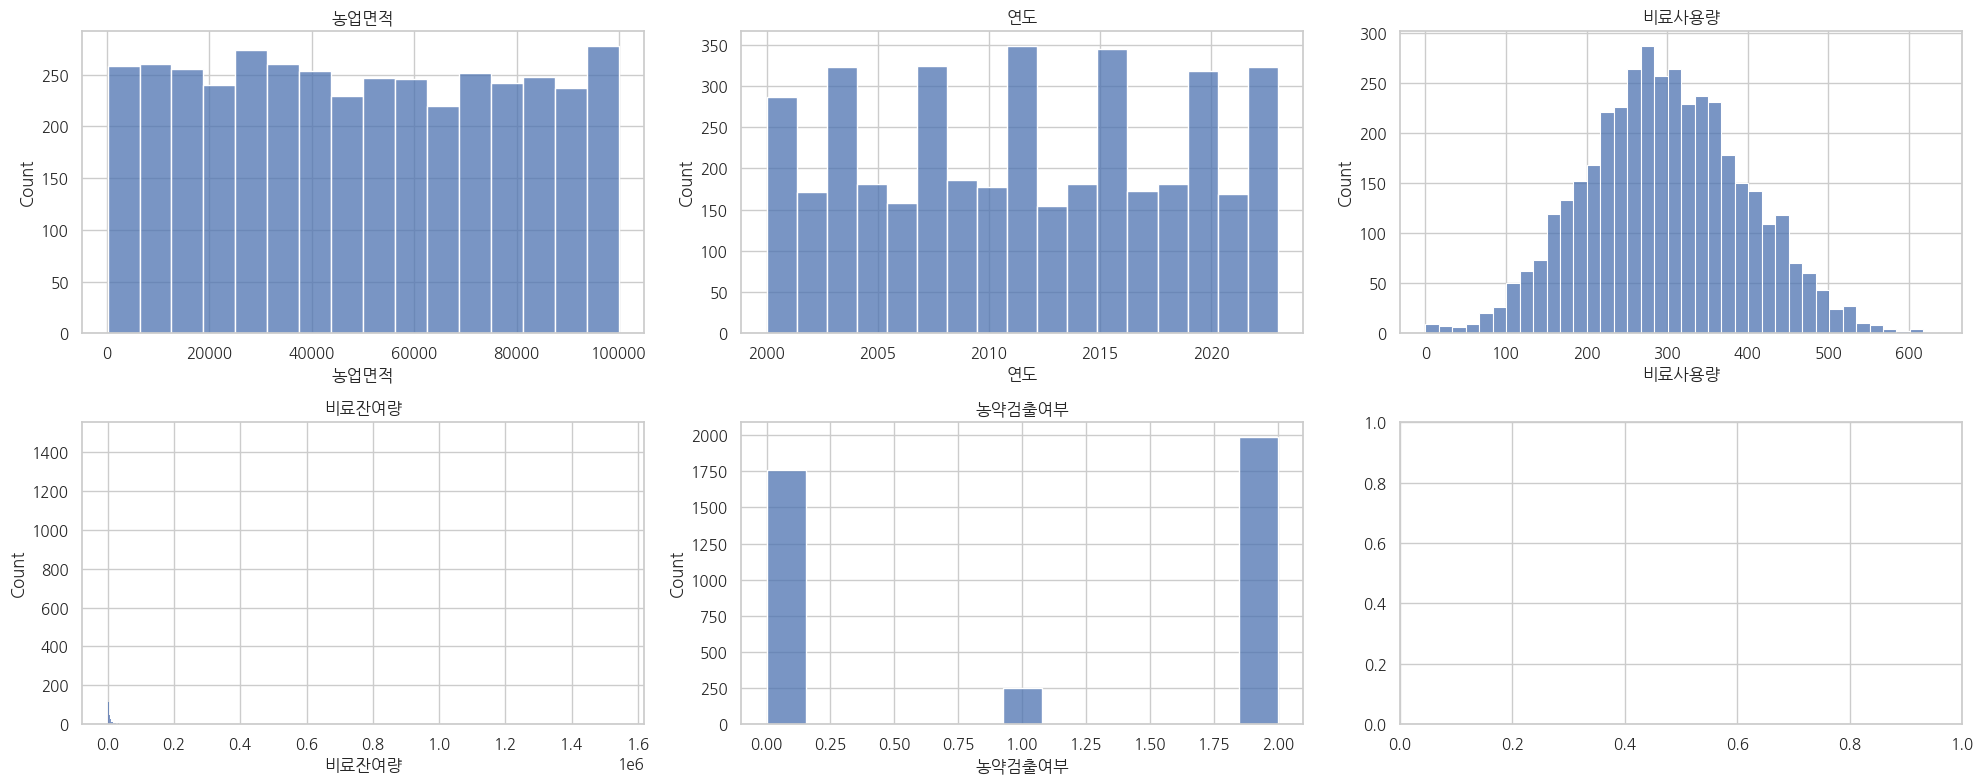

In [6]:
# 수치형 분포확인 
fig, axes = plt.subplots(2,3, figsize=(20,8))

sns.histplot(train['농업면적'], ax=axes[0][0])
axes[0][0].set_title('농업면적')
sns.histplot(train['연도'], ax=axes[0][1])
axes[0][1].set_title('연도')
sns.histplot(train['비료사용량'], ax=axes[0][2])
axes[0][2].set_title('비료사용량')
sns.histplot(train['비료잔여량'], ax=axes[1][0])
axes[1][0].set_title('비료잔여량')
sns.histplot(train['농약검출여부'], ax=axes[1][1])
axes[1][1].set_title('농약검출여부')

plt.tight_layout()
plt.show()

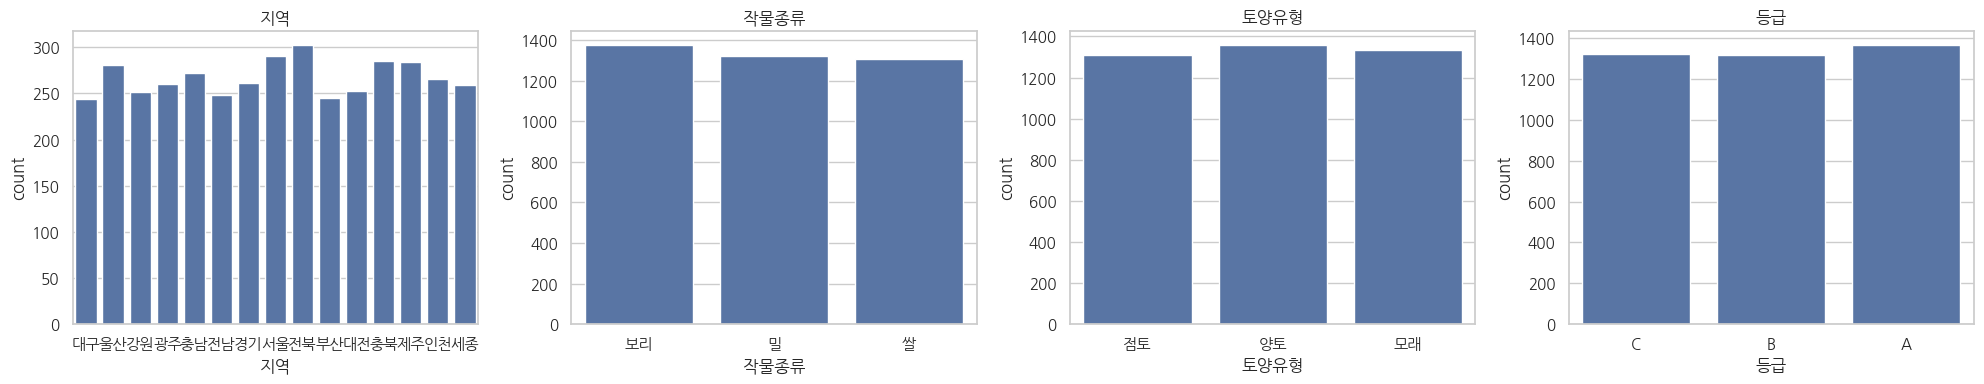

In [7]:
fig, axes = plt.subplots(1,4, figsize=(20,4))
sns.countplot(data=train, x=cat_cols[0], ax=axes[0])
sns.countplot(data=train, x=cat_cols[1], ax=axes[1])
sns.countplot(data=train, x=cat_cols[2], ax=axes[2])
sns.countplot(data=train, x=cat_cols[3], ax=axes[3])

axes[0].set_title(cat_cols[0])
axes[1].set_title(cat_cols[1])
axes[2].set_title(cat_cols[2])
axes[3].set_title(cat_cols[3])

plt.tight_layout()
plt.show()

,농업면적,연도,비료사용량,비료잔여량,농약검출여부
농업면적,1.000000,0.029259,-0.022732,-0.014235,0.010419
연도,0.029259,1.000000,0.014201,0.000714,-0.002171
비료사용량,-0.022732,0.014201,1.000000,0.007672,0.157655
비료잔여량,-0.014235,0.000714,0.007672,1.000000,-0.226701
농약검출여부,0.010419,-0.002171,0.157655,-0.226701,1.000000


<Axes: >

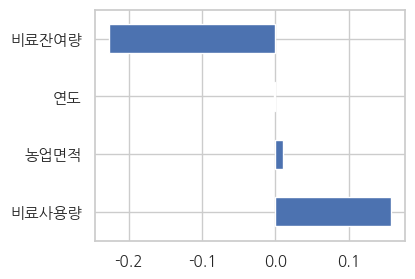

In [8]:
# 수치형 변수들과 농약검출여부의 상관관계
corr = train.corr(numeric_only=True)
display(corr)

plt.figure(figsize=(4,3))
corr['농약검출여부'].drop('농약검출여부').sort_values(ascending=False).plot(kind='barh')

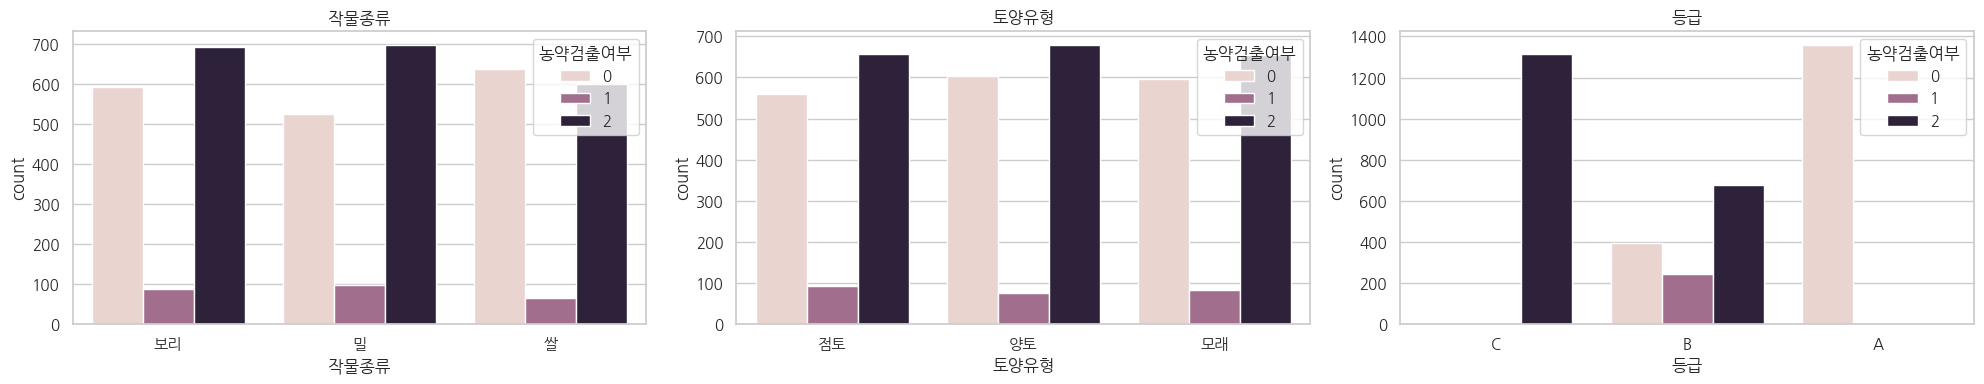

In [9]:
# 범주형 변수 - 농약검출 비교 
fig, axes = plt.subplots(1,3, figsize=(20,4))
sns.countplot(data=train, x=cat_cols[1], ax=axes[0], hue='농약검출여부')
sns.countplot(data=train, x=cat_cols[2], ax=axes[1], hue='농약검출여부')
sns.countplot(data=train, x=cat_cols[3], ax=axes[2], hue='농약검출여부')

axes[0].set_title(cat_cols[1])
axes[1].set_title(cat_cols[2])
axes[2].set_title(cat_cols[3])

plt.tight_layout()
plt.show()

- 결측치는 없고, 인코딩이 필요한 범주형 변수들이 있다. 
- 타겟변수(농약검출여부)의 클래스 불균형이 심하다. 
- "비료"와 "등급"이 농약검출여부에 미치는 영향이 큰 것 같다. 
---

In [10]:
# 범주형 원-핫 인코딩 
print('원본크기 =', train.shape, test.shape)

full = pd.concat([train, test], axis=0)
full = pd.get_dummies(full, columns=cat_cols)
train = full.iloc[:4000, :]
test = full.iloc[4000:, :]
test = test.drop('농약검출여부', axis=1)

print('인코딩후 크기 = ', train.shape, test.shape)

원본크기 = (4000, 9) (1000, 8)
인코딩후 크기 =  (4000, 29) (1000, 28)


In [11]:
# 타겟 분리, 검증데이터 분할 
y = train['농약검출여부']
X = train.drop('농약검출여부', axis=1)

from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

---
#### Baseline : RandomForest

RF's Accuracy =  0.96 
 RF's F1 =  0.878 
 RF's ROC_AUC =  0.9895

 [[343   4   4]
 [ 10  30  11]
 [  0   3 395]]


<Axes: >

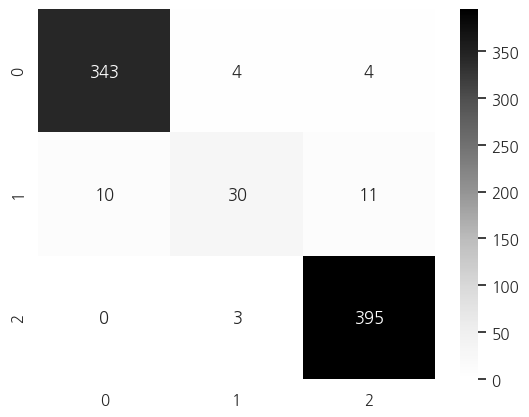

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

rf = RandomForestClassifier(random_state=120)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_valid)
rf_pred_proba = rf.predict_proba(X_valid)

acc = accuracy_score(y_valid, rf_pred)
f1 = f1_score(y_valid, rf_pred, average='macro')
roc = roc_auc_score(y_valid, rf_pred_proba, multi_class='ovr')

print(
    "RF's Accuracy = ", round(acc, 4),
    '\n', "RF's F1 = ", round(f1, 4),
    '\n', "RF's ROC_AUC = ", round(roc, 4)
)

cm = confusion_matrix(y_valid, rf_pred)
print('\n', cm)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greys")


--- 
#### Category Boost

In [13]:
####################################################################
# 범주형 데이터에 대한 원-핫 인코딩이 불필요한 점 등 장점이 있으나 
# 설정이 복잡하고 실행속도가 느린 편 
####################################################################

#!pip install catboost
from catboost import CatBoostClassifier

cb = CatBoostClassifier(
    loss_function='MultiClass',  ## 다중분류임을 명시 
    random_state=120,
    verbose=0
)

cb.fit(X_train, y_train)

cb_pred = cb.predict(X_valid)
cb_pred_proba = cb.predict_proba(X_valid)

acc = accuracy_score(y_valid, cb_pred)
f1 = f1_score(y_valid, cb_pred, average='macro')
roc = roc_auc_score(y_valid, cb_pred_proba, multi_class='ovr')

print(
    "CB's Accuracy = ", round(acc, 4),
    '\n', "CB's F1 = ", round(f1, 4),
    '\n', "CB's ROC_AUC = ", round(roc, 4)
)

CB's Accuracy =  0.975 
 CB's F1 =  0.9289 
 CB's ROC_AUC =  0.9972


--- 
#### LightGBM

In [21]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    objective='multiclass',  # 다중분류임을 명시 
    num_class=3,             # 3개로 분리해야함을 명시 
    random_state=120,
    verbose=-1              # 로그 출력 안 함
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric='multi_logloss'
)

lgb_pred_proba = lgb_model.predict_proba(X_valid)
lgb_pred = np.argmax(lgb_pred_proba, axis=1)

acc = accuracy_score(y_valid, lgb_pred)
f1 = f1_score(y_valid, lgb_pred, average='macro')
roc = roc_auc_score(y_valid, lgb_pred_proba, multi_class='ovr')

print("LightGBM Accuracy =", round(acc, 4))
print("LightGBM F1 =", round(f1, 4))
print("LightGBM ROC_AUC =", round(roc, 4))

LightGBM Accuracy = 0.9775
LightGBM F1 = 0.9332
LightGBM ROC_AUC = 0.9964


--- 
#### (Multinomial Logistic) Regression

In [15]:
## 선형모델은 변수 스케일링 필요 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train[num_cols[:-1]] = scaler.fit_transform(X_train[num_cols[:-1]])
X_valid[num_cols[:-1]] = scaler.transform(X_valid[num_cols[:-1]])
test[num_cols[:-1]] = scaler.transform(test[num_cols[:-1]])

# 모델, 평가 
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    multi_class='multinomial',
    random_state=120
)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_valid)
log_pred_proba = log_model.predict_proba(X_valid)

acc = accuracy_score(y_valid, log_pred)
f1 = f1_score(y_valid, log_pred, average='macro')
roc = roc_auc_score(y_valid, log_pred_proba, multi_class='ovr')

print("LogisticR Accuracy =", round(acc, 4))
print("LogisticR F1 =", round(f1, 4))
print("LogisticR ROC_AUC =", round(roc, 4))

LogisticR Accuracy = 0.8738
LogisticR F1 = 0.6036
LogisticR ROC_AUC = 0.9375


--- 
#### Summary 
- 1. RamdomForest :  Accuracy =  0.96 | F1 =  0.878 | ROC_AUC =  0.9895
- 2. CatBoost :  Accuracy =  0.975 | F1 =  0.9289 | ROC_AUC =  0.9972
- 3. LightGBM :  Accuracy = 0.9762 | F1 = 0.9299 | ROC-AUC = 0.9973
- 4. LogisticR : Accuracy = 0.8738 | F1 = 0.6036 | ROC-AUC = 0.9375

In [16]:
# 참고. complete the test.csv with LightGBM 
test_pred = lgb_model.predict(test)

test_new = test.copy()
test_new['농약검출여부'] = test_pred 
display(test_new.head())

## 참고. 보통 대회,시험에서는 예측결과만을 제출한다. 
test_new[['농약검출여부']].to_csv('submission.csv', index=False, encoding='utf-8-sig')

,농업면적,연도,비료사용량,비료잔여량,지역_강원,지역_경기,지역_광주,지역_대구,지역_대전,지역_부산,...,작물종류_밀,작물종류_보리,작물종류_쌀,토양유형_모래,토양유형_양토,토양유형_점토,등급_A,등급_B,등급_C,농약검출여부
0,-0.219547,-0.530701,-1.608139,-0.199658,False,False,False,False,False,False,...,False,True,False,False,False,True,False,True,False,2.0
1,1.649991,0.351503,0.767247,-0.147869,False,False,False,False,False,False,...,False,True,False,False,True,False,True,False,False,2.0
2,-0.087760,1.674811,-0.492085,-0.174322,False,False,False,False,True,False,...,False,False,True,False,False,True,False,True,False,2.0
3,1.140542,0.057435,-0.560860,-0.205563,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,True,2.0
4,0.832595,0.057435,-1.330801,-0.114195,False,False,True,False,False,False,...,True,False,False,False,False,True,True,False,False,2.0


--- 
#### 최적화 1 : Cross Validation 

In [22]:
#########################################################
# train 데이터를 3개로 나누어, 번갈아 학습&검증 수행 
#########################################################
from sklearn.model_selection import cross_val_score
f1 = cross_val_score(lgb_model, X_train, y_train, cv=3, scoring='f1_macro')

print('F1 score = ', f1) 
print('F1 score 평균 = ', f1.mean())

F1 score =  [0.90982198 0.90733441 0.9166594 ]
F1 score 평균 =  0.9112719293288406


--- 
#### [심화] 최적화 2 : GridSearch

In [23]:
#########################################################
# 이전 분석결과 또는 현업/분석가의 노하우에 의해 paran_grid 범위 설정 
# 실행에 장시간 소요됨 
#########################################################

from sklearn.model_selection import GridSearchCV

param_grid = {
    'num_leaves': [31, 50],
    'max_depth': [5, 10],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 300],
    'feature_fraction': [0.8, 1.0]
}

lgb_model = LGBMClassifier(objective='multiclass', num_class=3, random_state=120)

grid = GridSearchCV(lgb_model, 
                    param_grid, scoring='f1_macro', cv=3, 
                    verbose=1, n_jobs=-1)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000566 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 838
[LightGBM] [Info] Number of data points in the train set: 2133, number of used features: 28
[LightGBM] [Info] Start training from score -0.821535
[LightGBM] [Info] Start training from score -2.767445
[LightGBM] [Info] Start training from score -0.698318
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

---
#### [심화] 최적화 3 : RandomizedSearch

In [24]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'num_leaves': np.arange(20, 150, 10),
    'max_depth': np.arange(3, 15, 1),
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 300, 500, 1000],
    'feature_fraction': [0.6, 0.7, 0.8, 0.9, 1.0],
    'bagging_fraction': [0.6, 0.7, 0.8, 0.9, 1.0],
    'lambda_l1': [0, 0.1, 0.5, 1.0],
    'lambda_l2': [0, 0.1, 0.5, 1.0]
}

lgb_model = LGBMClassifier(objective='multiclass', num_class=3, random_state=120)

rand_search = RandomizedSearchCV(lgb_model, param_distributions=param_dist,
                                 n_iter=50, scoring='f1_macro', cv=3, verbose=1, random_state=42)
rand_search.fit(X_train, y_train)

print("Best params:", rand_search.best_params_)
print("Best score:", rand_search.best_score_)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best params: {'num_leaves': np.int64(130), 'n_estimators': 500, 'max_depth': np.int64(14), 'learning_rate': 0.1, 'lambda_l2': 1.0, 'lambda_l1': 1.0, 'feature_fraction': 1.0, 'bagging_fraction': 0.6}
Best score: 0.9189964241615057


In [ ]:
## RandomizedSearch에서 찾은 최적 파라미터를 사용한 예측 

best_params = {
    'num_leaves': 130,        # 리프 노드 최대 수
    'max_depth': 14,          # 트리 최대 깊이
    'learning_rate': 0.1,     # 학습률
    'n_estimators': 500,      # 부스팅 반복 횟수
    'feature_fraction': 1.0,  # 각 트리에서 사용할 feature 비율
    'bagging_fraction': 0.6,  # 샘플링 비율
    'lambda_l1': 1.0,         # L1 규제
    'lambda_l2': 1.0,         # L2 규제
    'objective': 'multiclass',# 다중분류 문제 명시
    'num_class': 3,           # 클래스 개수
    'random_state': 120,      # 시드 고정
    'verbose': -1             # 학습 로그 제거
}

# ==========================================
# train 데이터로 학습
# ==========================================
lgb_model = LGBMClassifier(**best_params)
lgb_model.fit(X_train, y_train)

# ==========================================
# 데이터 예측 (test는 이미 원-핫 인코딩, 스케일링 등 전처리 완료)
# ==========================================
test_pred = lgb_model.predict(test) 

# ==========================================
# 제출용 파일 
# ==========================================
test_new2 = test.copy()
test_new2['농약검출여부'] = test_pred 
display(test_new2.head())

## 참고. 보통 대회,시험에서는 예측결과만을 제출한다. 
test_new2[['농약검출여부']].to_csv('submission2.csv', index=False, encoding='utf-8-sig')

,농업면적,연도,비료사용량,비료잔여량,지역_강원,지역_경기,지역_광주,지역_대구,지역_대전,지역_부산,...,작물종류_밀,작물종류_보리,작물종류_쌀,토양유형_모래,토양유형_양토,토양유형_점토,등급_A,등급_B,등급_C,농약검출여부
0,-0.219547,-0.530701,-1.608139,-0.199658,False,False,False,False,False,False,...,False,True,False,False,False,True,False,True,False,2.0
1,1.649991,0.351503,0.767247,-0.147869,False,False,False,False,False,False,...,False,True,False,False,True,False,True,False,False,0.0
2,-0.087760,1.674811,-0.492085,-0.174322,False,False,False,False,True,False,...,False,False,True,False,False,True,False,True,False,0.0
3,1.140542,0.057435,-0.560860,-0.205563,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,True,2.0
4,0.832595,0.057435,-1.330801,-0.114195,False,False,True,False,False,False,...,True,False,False,False,False,True,True,False,False,0.0
